In [10]:
#import lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
#upload dataset

from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data (1).csv


In [11]:
# Load uploaded dataset

df = pd.read_csv("car data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
# Dataset information

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows:
2

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_ty

In [13]:
# ============================================
# DATA CLEANING
# ============================================

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

# Check missing values again
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicate rows after cleaning: 0
Dataset shape after cleaning: (299, 9)

Missing values after cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [14]:
# ============================================
# FEATURE ENGINEERING
# ============================================

# Calculate car age using the latest year in the dataset
reference_year = df["Year"].max()

df["Car_Age"] = reference_year - df["Year"]

print("Reference year:", reference_year)
print("\nCar age feature created successfully.")
print(df[["Year", "Car_Age"]].head())

print("\nUpdated dataset shape:", df.shape)

Reference year: 2018

Car age feature created successfully.
   Year  Car_Age
0  2014        4
1  2013        5
2  2017        1
3  2011        7
4  2014        4

Updated dataset shape: (299, 10)


In [15]:
# ============================================
# CHECK CATEGORICAL FEATURES
# ============================================

categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission",
    "Owner"
]

print("Unique values in categorical features:\n")

for column in categorical_columns:
    print(f"{column}:")
    print(df[column].unique())
    print()

Unique values in categorical features:

Fuel_Type:
['Petrol' 'Diesel' 'CNG']

Selling_type:
['Dealer' 'Individual']

Transmission:
['Manual' 'Automatic']

Owner:
[0 1 3]



In [16]:
# ============================================
# PREPARE FEATURES AND ENCODE CATEGORICAL DATA
# ============================================

# Drop Car_Name because it is a high-cardinality text feature
df_model = df.drop(columns=["Car_Name"])

# Convert categorical columns into numerical dummy variables
df_model = pd.get_dummies(
    df_model,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True,
    dtype=int
)

print("Categorical features encoded successfully.\n")

print("Final model columns:")
print(df_model.columns.tolist())

print("\nFinal model dataset shape:", df_model.shape)

df_model.head()

Categorical features encoded successfully.

Final model columns:
['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']

Final model dataset shape: (299, 10)


,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,4,0,1,0,1
1,2013,4.75,9.54,43000,0,5,1,0,0,1
2,2017,7.25,9.85,6900,0,1,0,1,0,1
3,2011,2.85,4.15,5200,0,7,0,1,0,1
4,2014,4.60,6.87,42450,0,4,1,0,0,1


In [17]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

# Target variable
y = df_model["Selling_Price"]

# Input features
X = df_model.drop(columns=["Selling_Price"])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (299, 9)
Target (y) shape: (299,)

Feature columns:
['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [10]:
# ============================================
# SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (239, 9)
Testing features shape: (60, 9)
Training target shape: (239,)
Testing target shape: (60,)


In [19]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (239, 9)
Testing features shape: (60, 9)
Training target shape: (239,)
Testing target shape: (60,)


In [20]:
# ============================================
# TRAIN LINEAR REGRESSION MODEL
# ============================================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [21]:
# ============================================
# PREDICT CAR PRICES
# ============================================

# Make predictions on unseen test data
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully.\n")

print("Actual Prices vs Predicted Prices:")
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(10))

Predictions generated successfully.

Actual Prices vs Predicted Prices:
   Actual Price  Predicted Price
0          8.99         7.500495
1          8.35         7.791134
2          0.45         1.365253
3          7.45         7.008954
4          5.25        11.165011
5          5.25         4.533817
6          5.85         8.491541
7          1.15         1.699151
8          9.25         8.822632
9          0.38        -0.963260


In [22]:
# ============================================
# EVALUATE LINEAR REGRESSION MODEL
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("LINEAR REGRESSION MODEL EVALUATION")
print("=" * 45)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

LINEAR REGRESSION MODEL EVALUATION
Mean Absolute Error (MAE): 1.4725
Mean Squared Error (MSE): 6.3731
Root Mean Squared Error (RMSE): 2.5245
R² Score: 0.7527


In [23]:
# ============================================
# TRAIN RANDOM FOREST REGRESSOR
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [24]:
# ============================================
# EVALUATE RANDOM FOREST REGRESSOR
# ============================================

# Generate predictions
rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("RANDOM FOREST REGRESSOR EVALUATION")
print("=" * 45)

print(f"Mean Absolute Error (MAE): {rf_mae:.4f}")
print(f"Mean Squared Error (MSE): {rf_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")

RANDOM FOREST REGRESSOR EVALUATION
Mean Absolute Error (MAE): 1.5533
Mean Squared Error (MSE): 14.1917
Root Mean Squared Error (RMSE): 3.7672
R² Score: 0.4494


In [25]:
# ============================================
# COMPARE REGRESSION MODELS
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "MSE": [
        mse,
        rf_mse
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R2 Score": [
        r2,
        rf_r2
    ]
})

print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

model_comparison.round(4)

MODEL PERFORMANCE COMPARISON


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.4725,6.3731,2.5245,0.7527
1,Random Forest Regressor,1.5533,14.1917,3.7672,0.4494


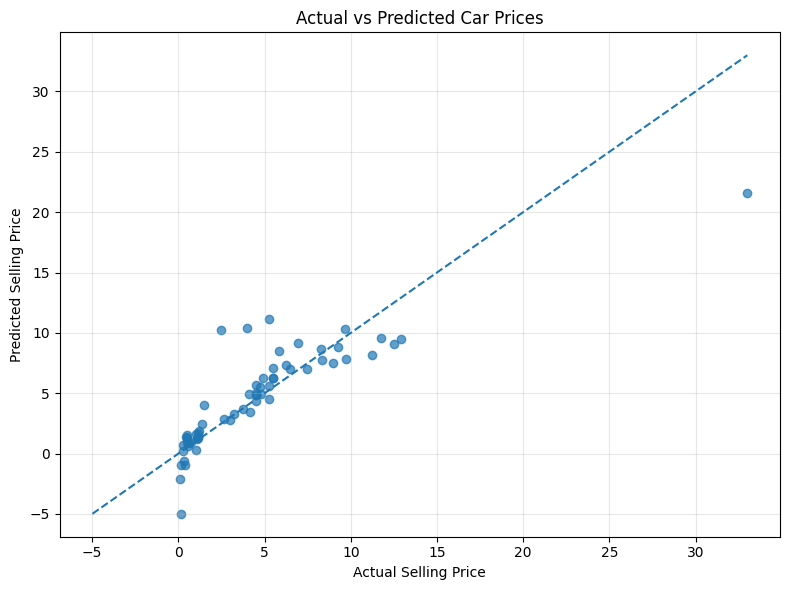

In [26]:
# ============================================
# ACTUAL VS PREDICTED CAR PRICES
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

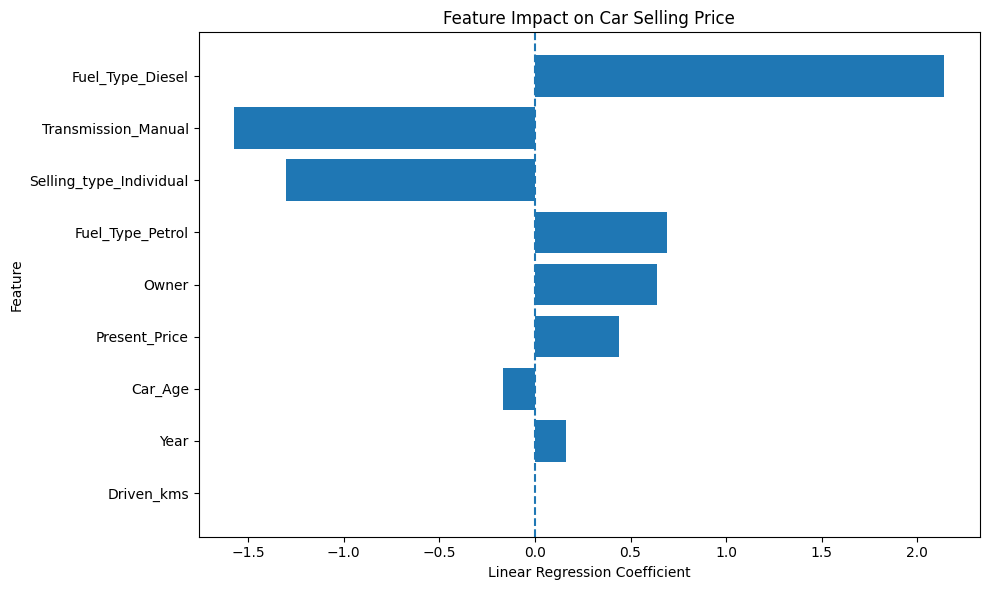

Feature Impact:
                   Feature  Coefficient
5         Fuel_Type_Diesel     2.142391
6         Fuel_Type_Petrol     0.692516
3                    Owner     0.640144
1            Present_Price     0.437119
0                     Year     0.165016
2               Driven_kms    -0.000011
4                  Car_Age    -0.165016
7  Selling_type_Individual    -1.302291
8      Transmission_Manual    -1.573425


In [27]:
# ============================================
# LINEAR REGRESSION FEATURE IMPACT
# ============================================

feature_impact = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Sort by absolute coefficient
feature_impact["Absolute_Impact"] = feature_impact["Coefficient"].abs()
feature_impact = feature_impact.sort_values(
    "Absolute_Impact",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_impact["Feature"],
    feature_impact["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Feature Impact on Car Selling Price")
plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

print("Feature Impact:")
print(
    feature_impact[
        ["Feature", "Coefficient"]
    ].sort_values(
        "Coefficient",
        ascending=False
    )
)

In [ ]:
# Save Actual vs Predicted visualization

import os

# Create visualization directory
visualization_dir = "Visualizations"
os.makedirs(visualization_dir, exist_ok=True)

# Recreate the graph
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "actual_vs_predicted_car_prices.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/actual_vs_predicted_car_prices.png")

In [31]:
# Save feature impact visualization

import os

# Create visualization directory
visualization_dir = "Visualizations"
os.makedirs(visualization_dir, exist_ok=True)

# Save current graph
plt.savefig(
    os.path.join(
        visualization_dir,
        "feature_impact_on_car_price.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

print("Saved: Visualizations/feature_impact_on_car_price.png")

Saved: Visualizations/feature_impact_on_car_price.png


<Figure size 640x480 with 0 Axes>


# CONCLUSION


print("=" * 70)
print("CONCLUSION - CAR PRICE PREDICTION WITH MACHINE LEARNING")
print("=" * 70)

print("""
This project demonstrated the use of Machine Learning for predicting
car selling prices based on features such as present price, car age,
driven kilometers, fuel type, transmission, selling type, and ownership.

The dataset was cleaned and preprocessed successfully, including the
removal of duplicate records and the creation of a new Car_Age feature.
Categorical variables were converted into numerical features using
one-hot encoding.

Two regression models were trained and evaluated:

1. Linear Regression
   - MAE  : 1.4725
   - MSE  : 6.3731
   - RMSE : 2.5245
   - R²   : 0.7527

2. Random Forest Regressor
   - MAE  : 1.5533
   - MSE  : 14.1917
   - RMSE : 3.7672
   - R²   : 0.4494

Based on the evaluation results, Linear Regression performed better
than the Random Forest Regressor on this dataset. It achieved a lower
MAE, MSE, and RMSE, along with a higher R² score of 0.7527.

The Actual vs Predicted visualization also helped evaluate how closely
the model predictions followed the actual car selling prices.
Additionally, the feature impact analysis showed how different
features influenced the predicted selling price.

Overall, the project demonstrates a complete machine learning workflow
including data cleaning, feature engineering, categorical encoding,
train-test splitting, model training, evaluation, and visualization.
It also highlights how regression techniques can be applied to
real-world car price prediction problems.
""")

print("=" * 70)
print("PROJECT CONCLUSION COMPLETED SUCCESSFULLY.")
print("=" * 70)